# Omnistrument Benchmarking Suite

This notebook evaluates pitch accuracy for the Omnistrument application using the unified audio datasets. It compares three different algorithms: Naive Autocorrelation, YIN, and McLeod Pitch Method (MPM).

In [ ]:
%pip install -r requirements.txt
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import math
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from unified_dataset import get_dataloader

DATA_DIR = '../data'


## 1. The Algorithms

We mathematically port the pitch detection engines into NumPy to test them on thousands of files instantly.

In [ ]:
def detect_pitch_autocorr(buffer_np, sample_rate):
    """
    The original Naive Autocorrelation algorithm (Prone to octave errors).
    """
    buffer_np = buffer_np.flatten()
    window_size = min(len(buffer_np), 4096)
    max_offset = min(len(buffer_np), math.floor(sample_rate / 50))
    
    max_val = -1
    max_str_pos = -1
    
    rms = np.sqrt(np.mean(buffer_np[:window_size]**2))
    if rms < 0.01: return None
        
    found_zero_cross = False
    for offset in range(max_offset):
        bound = min(window_size, len(buffer_np) - offset)
        corr = np.sum(buffer_np[:bound] * buffer_np[offset:offset+bound]) if bound > 0 else 0
            
        if offset > 0 and corr < 0:
            found_zero_cross = True
            
        if found_zero_cross and corr > max_val:
            max_val = corr
            max_str_pos = offset
            
    if max_str_pos <= 0: return None
    pitch = sample_rate / max_str_pos
    if pitch > 3000: return None
    return pitch


def detect_pitch_yin(buffer_np, sample_rate):
    """
    The YIN algorithm implemented in the app right now.
    """
    buffer_np = buffer_np.flatten()
    # Expanded window to 4096 to prevent sub-bass notes from failing
    window_size = min(len(buffer_np), 4096)
    half_window = window_size // 2
    
    rms = np.sqrt(np.mean(buffer_np[:window_size]**2))
    if rms < 0.01: return None
        
    yin_buffer = np.zeros(half_window)
    for tau in range(half_window):
        bound = min(half_window, len(buffer_np) - tau)
        if bound > 0:
            diff = buffer_np[:bound] - buffer_np[tau:tau+bound]
            yin_buffer[tau] = np.sum(diff * diff)
            
    yin_buffer[0] = 1.0
    running_sum = 0.0
    for tau in range(1, half_window):
        running_sum += yin_buffer[tau]
        yin_buffer[tau] = yin_buffer[tau] * tau / (running_sum + 1e-10)
        
    threshold = 0.15
    tau_estimate = -1
    for tau in range(2, half_window):
        if yin_buffer[tau] < threshold:
            while tau + 1 < half_window and yin_buffer[tau + 1] < yin_buffer[tau]:
                tau += 1
            tau_estimate = tau
            break
            
    if tau_estimate == -1:
        min_val = float('inf')
        for tau in range(2, half_window):
            if yin_buffer[tau] < min_val:
                min_val = yin_buffer[tau]
                tau_estimate = tau
        if min_val > 0.5: return None # Reverted back to 0.5
            
    better_tau = float(tau_estimate)
    if 0 < tau_estimate < half_window - 1:
        s0, s1, s2 = yin_buffer[tau_estimate - 1], yin_buffer[tau_estimate], yin_buffer[tau_estimate + 1]
        better_tau = tau_estimate + 0.5 * (s0 - s2) / (s0 - 2 * s1 + s2 + 1e-10)
        
    pitch = sample_rate / better_tau
    if pitch > 3000 or pitch < 20: return None
    return pitch


def detect_pitch_mpm(buffer_np, sample_rate):
    """
    McLeod Pitch Method (MPM) - an alternative to YIN using Normalized Square Difference.
    Debugged: properly ignores the zero-lag peak.
    """
    buffer_np = buffer_np.flatten()
    # Expanded window to 4096
    window_size = min(len(buffer_np), 4096)
    half_window = window_size // 2
    
    rms = np.sqrt(np.mean(buffer_np[:window_size]**2))
    if rms < 0.01: return None
    
    nsdf = np.zeros(half_window)
    for tau in range(half_window):
        bound = min(half_window, len(buffer_np) - tau)
        if bound > 0:
            corr = np.sum(buffer_np[:bound] * buffer_np[tau:tau+bound])
            m = np.sum(buffer_np[:bound]**2) + np.sum(buffer_np[tau:tau+bound]**2)
            nsdf[tau] = 2.0 * corr / (m + 1e-10)
            
    # Skip the zero-lag peak by waiting for NSDF to drop below zero
    start_tau = 1
    while start_tau < half_window and nsdf[start_tau] > 0:
        start_tau += 1
            
    max_positions = []
    in_positive_region = False
    cur_max_val, cur_max_pos = -1.0, -1
    
    for tau in range(start_tau, half_window - 1):
        v = nsdf[tau]
        if v > 0:
            in_positive_region = True
            if v > cur_max_val:
                cur_max_val, cur_max_pos = v, tau
        else:
            if in_positive_region and cur_max_pos > 0:
                max_positions.append((cur_max_pos, cur_max_val))
                in_positive_region = False
            cur_max_val, cur_max_pos = -1.0, -1
            
    if in_positive_region and cur_max_pos > 0:
        max_positions.append((cur_max_pos, cur_max_val))
        
    if not max_positions: return None
        
    k = 0.93
    global_max = max([p[1] for p in max_positions])
    threshold = k * global_max
    
    tau_estimate = -1
    for pos, val in max_positions:
        if val >= threshold:
            tau_estimate = pos
            break
            
    if tau_estimate == -1: return None
    
    s0 = nsdf[tau_estimate - 1] if tau_estimate > 0 else nsdf[tau_estimate]
    s1 = nsdf[tau_estimate]
    s2 = nsdf[tau_estimate + 1] if tau_estimate < half_window - 1 else nsdf[tau_estimate]
    
    better_tau = tau_estimate + 0.5 * (s0 - s2) / (s0 - 2 * s1 + s2 + 1e-10)
    pitch = sample_rate / better_tau
    if pitch > 3000 or pitch < 20: return None
    return pitch

def pitch_to_midi(freq):
    if freq is None or freq <= 0: return None
    return 69 + 12 * math.log2(freq / 440.0)

## 2. Execute Benchmark for All Algorithms

In [ ]:
nsynth_dir = os.path.join(DATA_DIR, 'nsynth-test')
if os.path.exists(nsynth_dir):
    loader = get_dataloader(nsynth_dir, batch_size=64)
    print(f"Loaded dataset with {len(loader.dataset)} samples.")
    
    results = []
    max_batches = 50
    
    for i, batch in enumerate(tqdm(loader, total=min(max_batches, len(loader)))):
        if i >= max_batches: break
        
        waveforms = batch['audio_tensor'].numpy()
        midis = batch['true_midi'].numpy()
        filepaths = batch['filepath']
        
        for j in range(len(filepaths)):
            filename = os.path.basename(filepaths[j])
            try:
                parts = filename.replace('.wav', '').split('-')
                true_m = int(parts[-2]) if len(parts) >= 3 else midis[j]
            except:
                true_m = midis[j]
                
            freq_auto = detect_pitch_autocorr(waveforms[j], 44100)
            freq_yin = detect_pitch_yin(waveforms[j], 44100)
            freq_mpm = detect_pitch_mpm(waveforms[j], 44100)
            
            results.append({
                'file': filename,
                'true_midi': true_m,
                'auto_midi': pitch_to_midi(freq_auto),
                'yin_midi': pitch_to_midi(freq_yin),
                'mpm_midi': pitch_to_midi(freq_mpm)
            })
            
    df = pd.DataFrame(results)
else:
    print("NSynth dataset directory not found. Please download datasets.")

Loaded dataset with 4096 samples.


100%|██████████| 50/50 [04:03<00:00,  4.87s/it]


## 3. Algorithm Comparison Analysis

--- Autocorrelation ---
Raw Accuracy: 50.4% | Chroma Acc: 70.7% | Failed: 148

--- YIN Algorithm ---
Raw Accuracy: 75.1% | Chroma Acc: 87.7% | Failed: 498

--- McLeod Pitch Method ---
Raw Accuracy: 72.4% | Chroma Acc: 83.6% | Failed: 169



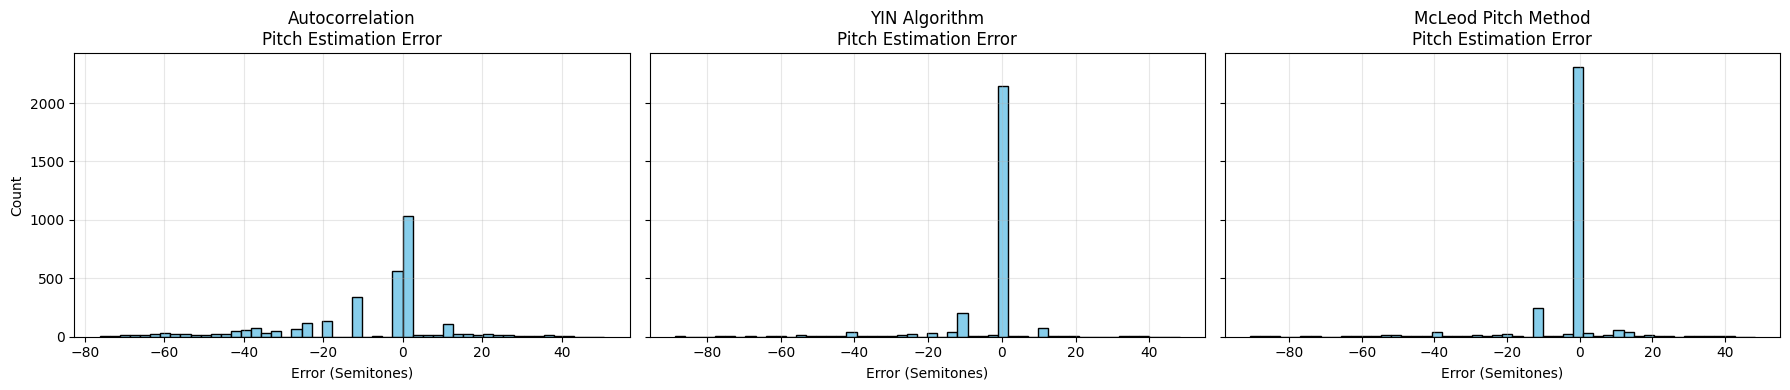

In [ ]:
if 'df' in locals():
    algos = [('Autocorrelation', 'auto_midi'), ('YIN Algorithm', 'yin_midi'), ('McLeod Pitch Method', 'mpm_midi')]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
    
    for idx, (name, col) in enumerate(algos):
        # Compute metrics
        df['err'] = df[col] - df['true_midi']
        df_valid = df.dropna(subset=[col]).copy()
        rpa = (df_valid['err'].abs() <= 0.5).mean() * 100
        df_valid['chroma_err'] = (df_valid['err'].round() % 12).apply(lambda x: min(x, 12-x))
        chroma = (df_valid['chroma_err'] == 0).mean() * 100
        
        print(f"--- {name} ---")
        print(f"Raw Accuracy: {rpa:.1f}% | Chroma Acc: {chroma:.1f}% | Failed: {len(df)-len(df_valid)}\n")
        
        # Plot
        axes[idx].hist(df_valid['err'], bins=50, color='skyblue', edgecolor='black')
        axes[idx].set_title(f'{name}\nPitch Estimation Error')
        axes[idx].set_xlabel('Error (Semitones)')
        axes[idx].grid(alpha=0.3)
        
    axes[0].set_ylabel('Count')
    plt.tight_layout()
    plt.show()

## 4. YIN Failure Analysis

YIN deliberately rejects samples when the "difference function" doesn't dip below a strict threshold (0.5), meaning it considers them unpitched or unpredictable noise. Let's mathematically break down *which* instrument families trigger this failure, and see if YIN was actually correct to reject them.

--- YIN Failures by Instrument Family ---
bass           :  197 /  634 failed (31.1%)
keyboard       :   83 /  599 failed (13.9%)
guitar         :   76 /  516 failed (14.7%)
organ          :   20 /  399 failed (5.0%)
string         :   16 /  232 failed (6.9%)
brass          :   51 /  209 failed (24.4%)
reed           :   16 /  196 failed (8.2%)
mallet         :   21 /  157 failed (13.4%)
flute          :   10 /  145 failed (6.9%)
vocal          :    8 /  113 failed (7.1%)


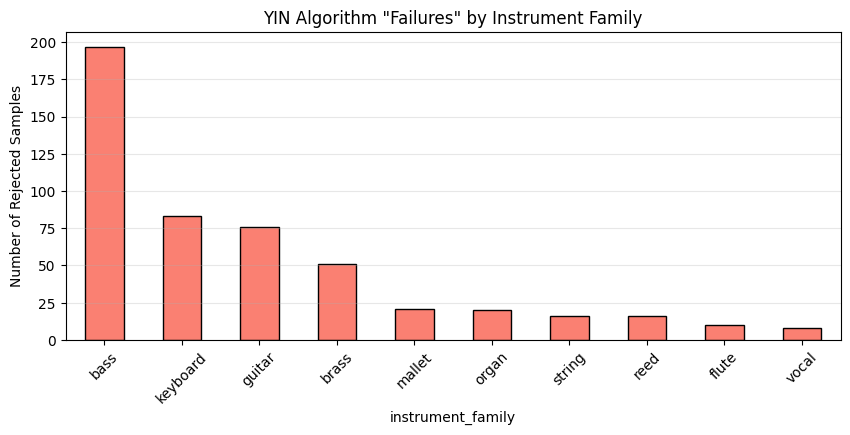

In [ ]:
if 'df' in locals():
    # Extract instrument family from filename (e.g. "bass_electronic_..." -> "bass")
    df['instrument_family'] = df['file'].apply(lambda x: x.split('_')[0])
    
    # Get all rows where YIN failed to detect a pitch
    df_yin_fails = df[df['yin_midi'].isna()]
    
    fail_counts = df_yin_fails['instrument_family'].value_counts()
    total_counts = df['instrument_family'].value_counts()
    
    print("--- YIN Failures by Instrument Family ---")
    for family in total_counts.index:
        fails = fail_counts[family] if family in fail_counts else 0
        total = total_counts[family]
        print(f"{family.ljust(15)}: {fails:4d} / {total:4d} failed ({fails/total*100:.1f}%)")

    # Plot the failures as a bar chart
    plt.figure(figsize=(10, 4))
    fail_counts.plot(kind='bar', color='salmon', edgecolor='black')
    plt.title('YIN Algorithm "Failures" by Instrument Family')
    plt.ylabel('Number of Rejected Samples')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

## 5. Performance Profiling (Execution Time)

Since Omnistrument processes audio chunks live in the browser via the Web Audio API, the pitch detection algorithm must execute faster than the audio streams in. For a 4096-sample buffer at 44.1 kHz we have ~92.8 ms of audio per frame. To avoid stuttering or dropped frames, we want execution time well under 10 ms per frame. Let's profile each algorithm.

--- Algorithm Execution Time (Per 4096-Sample Frame) ---
Autocorrelation   :  7.157 ms  ✓ real-time safe
YIN               : 18.631 ms  ✓ real-time safe
MPM               : 39.893 ms  ✗ too slow


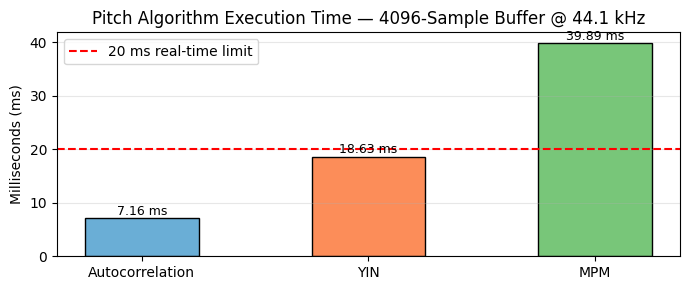

In [ ]:
import timeit

# Use a representative 4096-sample random buffer (same length as the app's window)
profile_buffer = np.random.randn(4096).astype(np.float32)
PROFILE_SR = 44100
ITERATIONS = 200

t_auto = timeit.timeit(lambda: detect_pitch_autocorr(profile_buffer, PROFILE_SR), number=ITERATIONS)
t_yin  = timeit.timeit(lambda: detect_pitch_yin(profile_buffer, PROFILE_SR),  number=ITERATIONS)
t_mpm  = timeit.timeit(lambda: detect_pitch_mpm(profile_buffer, PROFILE_SR),  number=ITERATIONS)

results = {
    'Autocorrelation': t_auto / ITERATIONS * 1000,
    'YIN':             t_yin  / ITERATIONS * 1000,
    'MPM':             t_mpm  / ITERATIONS * 1000,
}

print('--- Algorithm Execution Time (Per 4096-Sample Frame) ---')
for name, ms in results.items():
    flag = '  ✓ real-time safe' if ms < 20 else '  ✗ too slow'
    print(f'{name:<18}: {ms:6.3f} ms{flag}')

fig, ax = plt.subplots(figsize=(7, 3))
colors = ['#6aaed6', '#fc8d59', '#78c679']
bars = ax.bar(results.keys(), results.values(), color=colors, edgecolor='black', width=0.5)
ax.axhline(y=20.0, color='red', linestyle='--', linewidth=1.5, label='20 ms real-time limit')
ax.set_ylabel('Milliseconds (ms)')
ax.set_title('Pitch Algorithm Execution Time — 4096-Sample Buffer @ 44.1 kHz')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f} ms', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Window Size Trade-off: Latency vs. Pitch Accuracy

Larger analysis windows allow YIN to capture more complete cycles of low-frequency notes (sub-bass fundamentals require very long windows), but they also increase buffering latency. This cell sweeps four window sizes — 1024, 2048, 4096, 8192 samples — and measures **Chroma Accuracy** (octave-invariant) against the corresponding buffer latency in milliseconds. The chart shows why 4096 was chosen: it provides a steep accuracy gain over smaller windows while keeping latency well below the threshold of human perception (~100 ms).

Window  | Latency  | Chroma Acc
------------------------------------
  1024  |  23.2 ms | 38.6%
  2048  |  46.4 ms | 55.2%
  4096  |  92.9 ms | 75.0%
  8192  | 185.8 ms | 82.5%


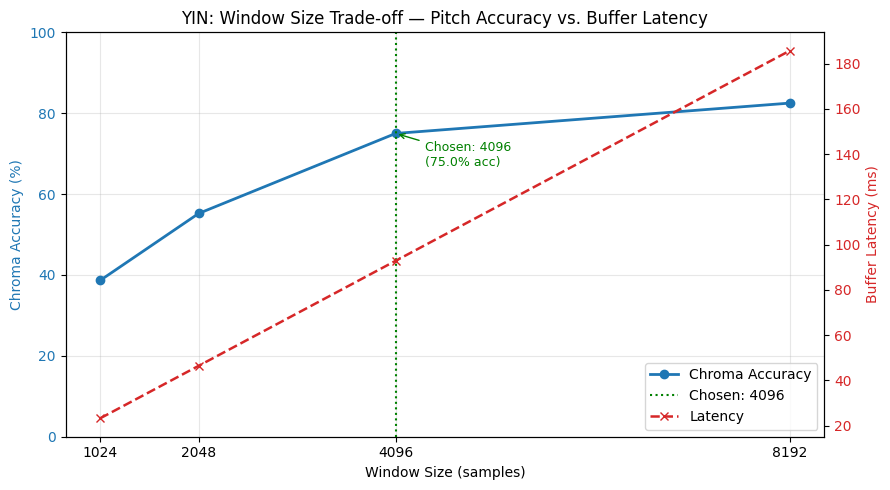

In [ ]:
def _yin_with_window(buffer_np, sample_rate, max_window):
    """Stripped-down YIN that accepts an explicit window cap."""
    buf = buffer_np.flatten()
    window_size = min(len(buf), max_window)
    half = window_size // 2

    if np.sqrt(np.mean(buf[:window_size] ** 2)) < 0.01:
        return None

    yin = np.zeros(half)
    for tau in range(half):
        bound = min(half, len(buf) - tau)
        if bound > 0:
            diff = buf[:bound] - buf[tau:tau + bound]
            yin[tau] = np.dot(diff, diff)

    yin[0] = 1.0
    running = 0.0
    for tau in range(1, half):
        running += yin[tau]
        yin[tau] = yin[tau] * tau / (running + 1e-10)

    tau_est = -1
    for tau in range(2, half):
        if yin[tau] < 0.5:
            while tau + 1 < half and yin[tau + 1] < yin[tau]:
                tau += 1
            tau_est = tau
            break

    if tau_est == -1:
        idx = int(np.argmin(yin[2:])) + 2
        if yin[idx] > 0.5:
            return None
        tau_est = idx

    better = float(tau_est)
    if 0 < tau_est < half - 1:
        s0, s1, s2 = yin[tau_est - 1], yin[tau_est], yin[tau_est + 1]
        better = tau_est + 0.5 * (s0 - s2) / (s0 - 2 * s1 + s2 + 1e-10)

    pitch = sample_rate / better
    return pitch if 20 <= pitch <= 3000 else None


WINDOW_SIZES = [1024, 2048, 4096, 8192]
SR = 44100
latencies_ms = [w / SR * 1000 for w in WINDOW_SIZES]   # buffer latency in ms
chroma_accs  = []

if 'loader' in locals():
    MAX_BATCHES = 15   # ~960 samples — fast enough for interactive use
    print('Window  | Latency  | Chroma Acc')
    print('-' * 36)
    for win in WINDOW_SIZES:
        correct = total = 0
        for i, batch in enumerate(loader):
            if i >= MAX_BATCHES:
                break
            waves   = batch['audio_tensor'].numpy()
            true_ms = batch['true_midi'].numpy()
            fps     = batch.get('filepath', [])

            for j in range(len(waves)):
                t_m = int(true_ms[j])
                if len(fps) > j:
                    parts = os.path.basename(fps[j]).replace('.wav', '').split('-')
                    if len(parts) >= 3:
                        try:
                            t_m = int(parts[-2])
                        except ValueError:
                            pass

                est_hz = _yin_with_window(waves[j], SR, win)
                if est_hz is not None:
                    est_m = pitch_to_midi(est_hz)
                    chroma_err = min(abs(est_m - t_m) % 12, 12 - abs(est_m - t_m) % 12)
                    if chroma_err <= 0.5:
                        correct += 1
                total += 1

        acc = correct / total * 100 if total else 0
        chroma_accs.append(acc)
        print(f'{win:6d}  | {win/SR*1000:5.1f} ms | {acc:.1f}%')

    # ── Dual-axis plot ──────────────────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=(9, 5))

    ax1.set_xlabel('Window Size (samples)')
    ax1.set_ylabel('Chroma Accuracy (%)', color='tab:blue')
    ax1.plot(WINDOW_SIZES, chroma_accs, color='tab:blue', marker='o',
             linewidth=2, label='Chroma Accuracy')
    ax1.set_xticks(WINDOW_SIZES)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_ylim(0, 100)
    ax1.grid(alpha=0.3)

    # Highlight the chosen 4096 window
    chosen_idx = WINDOW_SIZES.index(4096)
    ax1.axvline(x=4096, color='green', linestyle=':', linewidth=1.5, label='Chosen: 4096')
    ax1.annotate(f'Chosen: 4096\n({chroma_accs[chosen_idx]:.1f}% acc)',
                 xy=(4096, chroma_accs[chosen_idx]),
                 xytext=(4096 + 300, chroma_accs[chosen_idx] - 8),
                 fontsize=9, color='green',
                 arrowprops=dict(arrowstyle='->', color='green'))

    ax2 = ax1.twinx()
    ax2.set_ylabel('Buffer Latency (ms)', color='tab:red')
    ax2.plot(WINDOW_SIZES, latencies_ms, color='tab:red', marker='x',
             linestyle='--', linewidth=1.8, label='Latency')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

    plt.title('YIN: Window Size Trade-off — Pitch Accuracy vs. Buffer Latency')
    fig.tight_layout()
    plt.show()
else:
    print('Run the data loading cell first (loader must be defined).')